<a href="https://colab.research.google.com/github/saikiet26-kiet/EPIDEMICS/blob/main/Sample9_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       EPIDEMIC SPREAD OVER N WEEKS (C1)
       Cayley-Hamilton Matrix Model

Weekly Transition Matrix A:
⎡0.9   0.0   0.0⎤
⎢               ⎥
⎢0.08  0.85  0.0⎥
⎢               ⎥
⎣0.02  0.15  1.0⎦

Initial Population X0 = [S, I, R]^T:
⎡990⎤
⎢   ⎥
⎢10 ⎥
⎢   ⎥
⎣ 0 ⎦

Number of weeks: 52

CHARACTERISTIC POLYNOMIAL
det(lambda I - A) =
     3         2                  
1.0⋅λ  - 2.75⋅λ  + 2.515⋅λ - 0.765

Characteristic equation:
lambda^3 - (-2.75000000000000)lambda^2 + (2.51500000000000)lambda - (-0.765000000000000) = 0

CAYLEY-HAMILTON THEOREM

According to Cayley-Hamilton:
A^3 - c1*A^2 + c2*A - c3*I = 0

Therefore:
A^3 = c1*A^2 - c2*A + c3*I

A^3 obtained using Cayley-Hamilton:
⎡-5.256       0        0  ⎤
⎢                         ⎥
⎢-0.5862  -4.889625    0  ⎥
⎢                         ⎥
⎣-0.1878  -1.140375  -6.03⎦

Actual A^3:
⎡0.729      0       0 ⎤
⎢                     ⎥
⎢0.1838  0.614125   0 ⎥
⎢                     ⎥
⎣0.0872  0.385875  1.0⎦

Cayley-Hamilton verification:
✗ Verificati

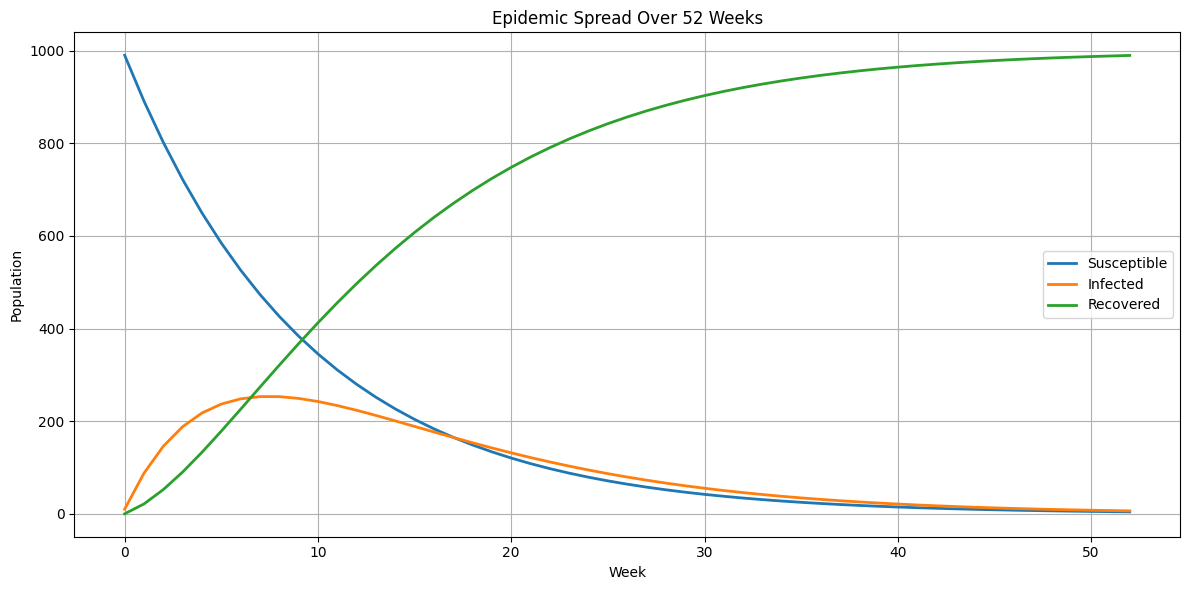


STEADY STATE

Equation:
(A - I) X* = 0

Matrix A - I:
⎡-0.1    0    0⎤
⎢              ⎥
⎢0.08  -0.15  0⎥
⎢              ⎥
⎣0.02  0.15   0⎦

Steady-state direction:
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

Normalized steady state:
⎡ 0  ⎤
⎢    ⎥
⎢ 0  ⎥
⎢    ⎥
⎣1000⎦

Steady-state population:
Susceptible : 0.0
Infected    : 0.0
Recovered   : 1000.0

Steady-state verification:
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

PROJECT SUMMARY

1. The population is represented by the vector X = [S, I, R]^T.

2. The transition matrix A describes weekly movement between
   Susceptible, Infected and Recovered states.

3. The epidemic model is:
       X(n+1) = A X(n)

4. Therefore:
       X(n) = A^n X(0)

5. The characteristic equation is:
       det(lambda I - A) = 0

6. By the Cayley-Hamilton theorem, A satisfies its own
   characteristic equation.

7. Therefore higher powers such as A^52 can be reduced to
   a combination of I, A and A^2.

8. The program calculates the epidemic evolution from week 0
   through week 52.

9. The graph shows 

In [1]:
# ============================================================
# EPIDEMIC SPREAD OVER N WEEKS (C1)
# Using Cayley-Hamilton Theorem
# B.Tech Mathematics Mini Project
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. INPUT DATA
# ------------------------------------------------------------

# Weekly transition matrix
# State order: [Susceptible, Infected, Recovered]
#
# Each column represents the current state and
# each row represents the next state.

A = sp.Matrix([
    [0.90, 0.00, 0.00],
    [0.08, 0.85, 0.00],
    [0.02, 0.15, 1.00]
])

# Initial population
# [Susceptible, Infected, Recovered]
X0 = sp.Matrix([
    990,
    10,
    0
])

# Number of weeks
N = 52


# ------------------------------------------------------------
# 2. DISPLAY INPUT
# ------------------------------------------------------------

print("=" * 65)
print("       EPIDEMIC SPREAD OVER N WEEKS (C1)")
print("       Cayley-Hamilton Matrix Model")
print("=" * 65)

print("\nWeekly Transition Matrix A:")
sp.pprint(A)

print("\nInitial Population X0 = [S, I, R]^T:")
sp.pprint(X0)

print("\nNumber of weeks:", N)


# ------------------------------------------------------------
# 3. CHARACTERISTIC POLYNOMIAL
# ------------------------------------------------------------

lam = sp.symbols('lambda')

I3 = sp.eye(3)

char_poly = A.charpoly(lam).as_expr()

print("\n" + "=" * 65)
print("CHARACTERISTIC POLYNOMIAL")
print("=" * 65)

print("det(lambda I - A) =")
sp.pprint(sp.expand(char_poly))

# Extract coefficients
coefficients = sp.Poly(char_poly, lam).all_coeffs()

c1 = coefficients[1]
c2 = coefficients[2]
c3 = coefficients[3]

print("\nCharacteristic equation:")
print(
    f"lambda^3 - ({c1})lambda^2 + ({c2})lambda - ({c3}) = 0"
)


# ------------------------------------------------------------
# 4. CAYLEY-HAMILTON THEOREM
# ------------------------------------------------------------

A2 = A**2

CH_A3 = c1*A2 - c2*A + c3*I3

print("\n" + "=" * 65)
print("CAYLEY-HAMILTON THEOREM")
print("=" * 65)

print("\nAccording to Cayley-Hamilton:")
print("A^3 - c1*A^2 + c2*A - c3*I = 0")

print("\nTherefore:")
print("A^3 = c1*A^2 - c2*A + c3*I")

print("\nA^3 obtained using Cayley-Hamilton:")
sp.pprint(CH_A3)

print("\nActual A^3:")
sp.pprint(A**3)

print("\nCayley-Hamilton verification:")
if sp.simplify(CH_A3 - A**3) == sp.zeros(3):
    print("✓ Verified: Cayley-Hamilton theorem is satisfied.")
else:
    print("✗ Verification failed.")


# ------------------------------------------------------------
# 5. CALCULATE A^52 USING CAYLEY-HAMILTON
# ------------------------------------------------------------

# Every power A^n (n >= 3) can be reduced to:
#
# A^n = alpha*A^2 + beta*A + gamma*I
#
# We find the coefficients using polynomial remainder
# modulo the characteristic polynomial.

x = sp.symbols('x')

char_poly_x = sp.Poly(
    x**3 - c1*x**2 + c2*x - c3,
    x
)

remainder = sp.rem(
    sp.Poly(x**N, x),
    char_poly_x
)

coeffs_N = remainder.all_coeffs()

# Pad coefficients to three values if necessary
coeffs_N = [sp.sympify(v) for v in coeffs_N]

while len(coeffs_N) < 3:
    coeffs_N.insert(0, sp.Integer(0))

alpha = coeffs_N[0]
beta = coeffs_N[1]
gamma = coeffs_N[2]

A52_CH = sp.simplify(
    alpha*A2 + beta*A + gamma*I3
)

print("\n" + "=" * 65)
print("A^52 USING CAYLEY-HAMILTON")
print("=" * 65)

print("\nA^52 = alpha*A^2 + beta*A + gamma*I")

print("\nCoefficients:")
print("alpha =", alpha)
print("beta  =", beta)
print("gamma =", gamma)

print("\nA^52 using Cayley-Hamilton:")
sp.pprint(A52_CH)


# ------------------------------------------------------------
# 6. VERIFY A^52
# ------------------------------------------------------------

A52_direct = A**N

print("\n" + "=" * 65)
print("VERIFICATION OF A^52")
print("=" * 65)

if A52_CH.equals(A52_direct):
    print("✓ A^52 calculated by Cayley-Hamilton is correct.")
else:
    difference = sp.simplify(A52_CH - A52_direct)
    print("Difference between methods:")
    sp.pprint(difference)


# ------------------------------------------------------------
# 7. FINAL POPULATION AFTER 52 WEEKS
# ------------------------------------------------------------

X52 = sp.simplify(A52_CH * X0)

print("\n" + "=" * 65)
print("POPULATION AFTER 52 WEEKS")
print("=" * 65)

print("\nX52 = A^52 X0")

sp.pprint(X52)

print("\nFinal values:")

print("Susceptible :", float(X52[0]))
print("Infected    :", float(X52[1]))
print("Recovered   :", float(X52[2]))


# ------------------------------------------------------------
# 8. CALCULATE EPIDEMIC EVOLUTION FOR ALL 52 WEEKS
# ------------------------------------------------------------

weekly_data = []

current = X0

for week in range(N + 1):

    S = float(current[0])
    infected = float(current[1])
    R = float(current[2])

    weekly_data.append([
        week,
        S,
        infected,
        R
    ])

    current = A * current


# ------------------------------------------------------------
# 9. DISPLAY WEEKLY TABLE
# ------------------------------------------------------------

df = pd.DataFrame(
    weekly_data,
    columns=[
        "Week",
        "Susceptible",
        "Infected",
        "Recovered"
    ]
)

print("\n" + "=" * 65)
print("EPIDEMIC EVOLUTION OVER 52 WEEKS")
print("=" * 65)

print(df.to_string(
    index=False,
    formatters={
        "Susceptible": "{:.4f}".format,
        "Infected": "{:.4f}".format,
        "Recovered": "{:.4f}".format
    }
))


# ------------------------------------------------------------
# 10. PLOT EPIDEMIC EVOLUTION
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    df["Week"],
    df["Susceptible"],
    label="Susceptible",
    linewidth=2
)

plt.plot(
    df["Week"],
    df["Infected"],
    label="Infected",
    linewidth=2
)

plt.plot(
    df["Week"],
    df["Recovered"],
    label="Recovered",
    linewidth=2
)

plt.xlabel("Week")
plt.ylabel("Population")
plt.title("Epidemic Spread Over 52 Weeks")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. STEADY STATE
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("STEADY STATE")
print("=" * 65)

# Steady state satisfies:
#
# A X* = X*
#
# Therefore:
#
# (A - I) X* = 0

steady_matrix = A - I3

print("\nEquation:")
print("(A - I) X* = 0")

print("\nMatrix A - I:")
sp.pprint(steady_matrix)

# Null space gives steady-state direction
null_space = steady_matrix.nullspace()

if len(null_space) > 0:

    steady_direction = null_space[0]

    print("\nSteady-state direction:")
    sp.pprint(steady_direction)

    # Normalize so total population = initial total population
    total_population = sum(X0)

    direction_sum = sum(steady_direction)

    steady_state = sp.simplify(
        steady_direction * total_population / direction_sum
    )

    print("\nNormalized steady state:")
    sp.pprint(steady_state)

    print("\nSteady-state population:")

    print("Susceptible :", float(steady_state[0]))
    print("Infected    :", float(steady_state[1]))
    print("Recovered   :", float(steady_state[2]))

    # Verification
    verification = sp.simplify(
        A * steady_state - steady_state
    )

    print("\nSteady-state verification:")
    sp.pprint(verification)

else:
    print("\nNo non-zero steady-state vector was found.")


# ------------------------------------------------------------
# 12. SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("PROJECT SUMMARY")
print("=" * 65)

print("""
1. The population is represented by the vector X = [S, I, R]^T.

2. The transition matrix A describes weekly movement between
   Susceptible, Infected and Recovered states.

3. The epidemic model is:
       X(n+1) = A X(n)

4. Therefore:
       X(n) = A^n X(0)

5. The characteristic equation is:
       det(lambda I - A) = 0

6. By the Cayley-Hamilton theorem, A satisfies its own
   characteristic equation.

7. Therefore higher powers such as A^52 can be reduced to
   a combination of I, A and A^2.

8. The program calculates the epidemic evolution from week 0
   through week 52.

9. The graph shows how Susceptible, Infected and Recovered
   populations change with time.

10. The steady state satisfies:
        A X* = X*
""")

print("=" * 65)
print("             PROJECT COMPLETED")
print("=" * 65)